<a href="https://colab.research.google.com/github/matteosisti/Foundamental_Ai/blob/main/notebooks/EDA/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


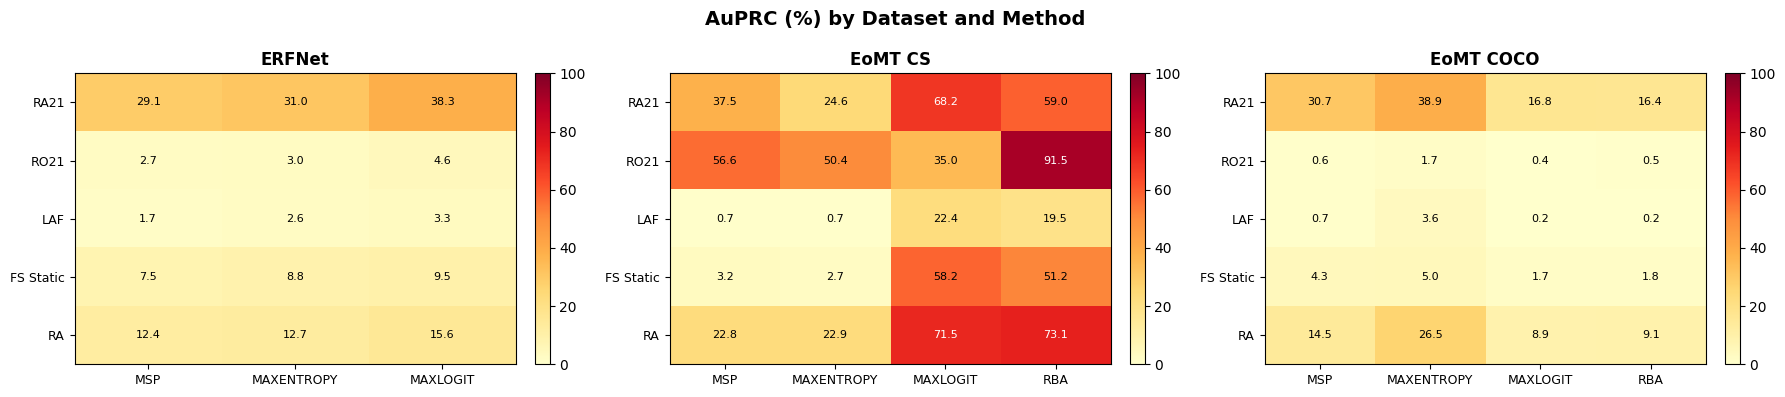

Saved eda_01_auprc_heatmap.png


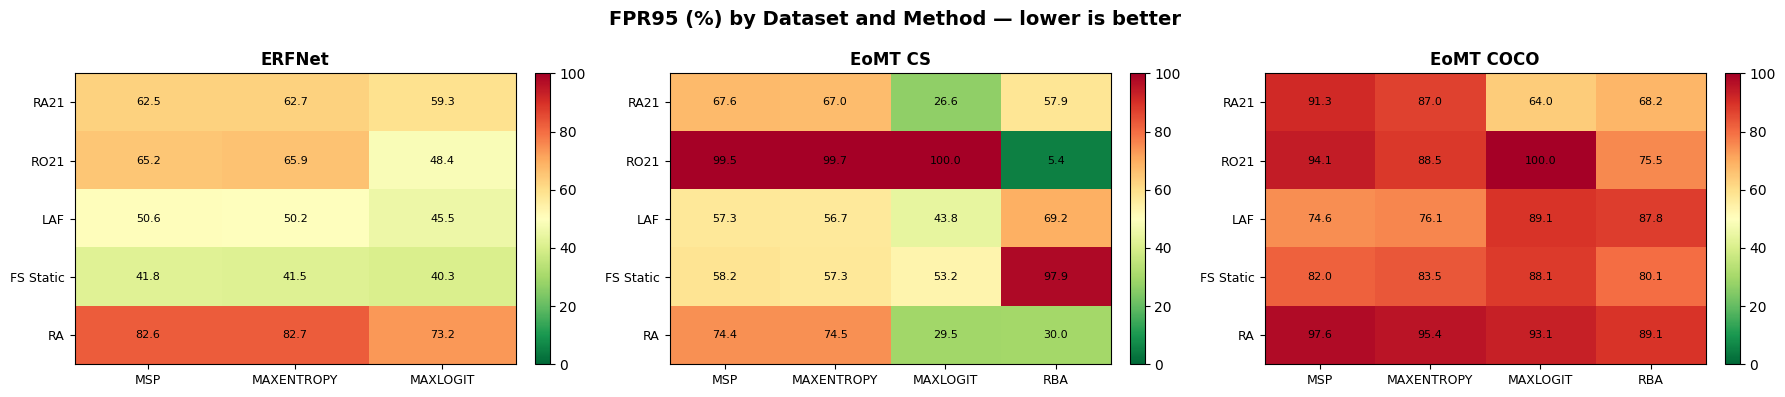

Saved eda_02_fpr95_heatmap.png


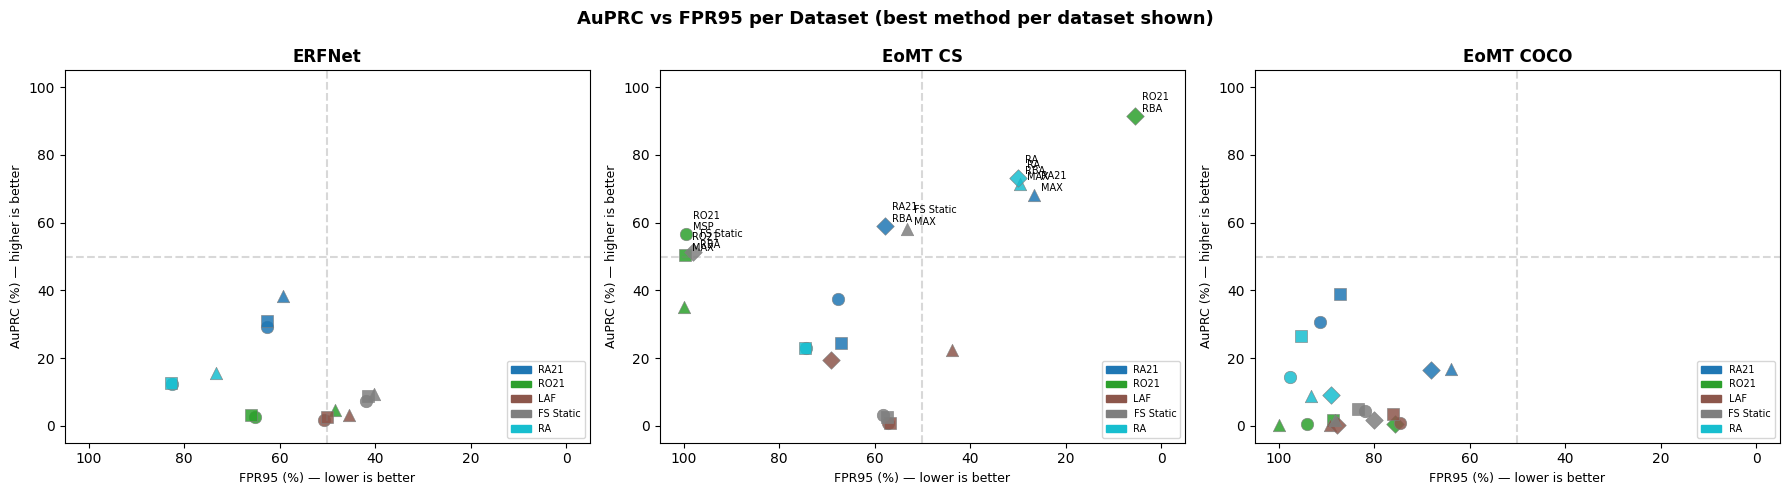

Saved eda_03_scatter.png


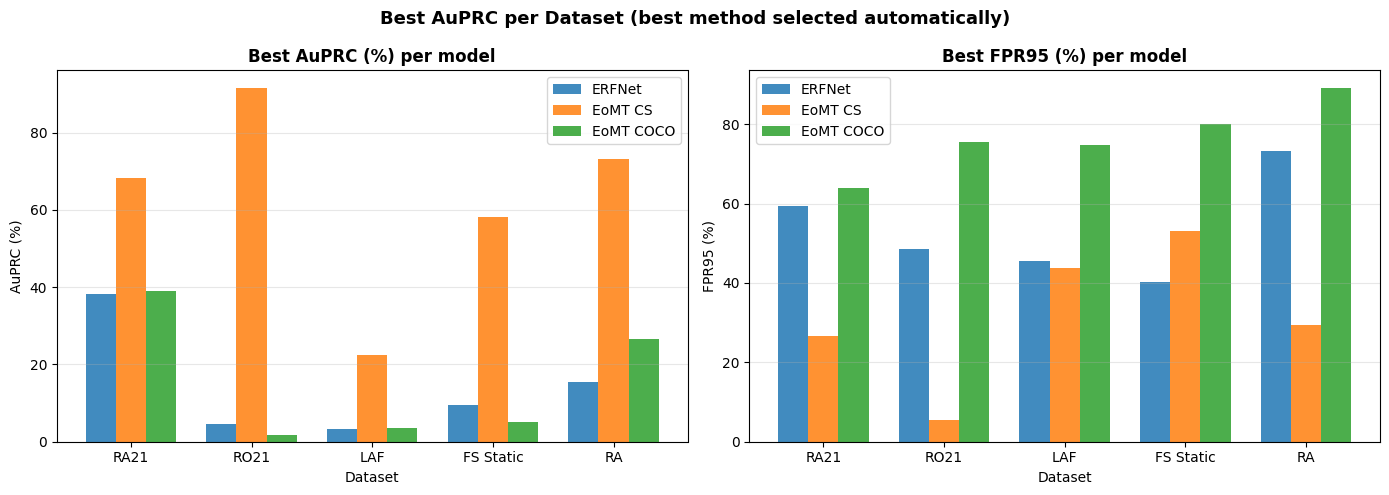

Saved eda_04_best_method_bar.png

All EDA figures saved to /content/drive/MyDrive/anom_project/results/eda


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# ── Config ──────────────────────────────────────────────────
JSON_PATH = '/content/drive/MyDrive/anom_project/all_results.json'
OUT_DIR   = '/content/drive/MyDrive/anom_project/results/eda'
os.makedirs(OUT_DIR, exist_ok=True)

with open(JSON_PATH) as f:
    data = json.load(f)

DATASETS  = ['RA21', 'RO21', 'LAF', 'fs_static', 'RA']
DS_LABELS = ['RA21', 'RO21', 'LAF', 'FS Static', 'RA']
METHODS   = ['msp', 'maxentropy', 'maxlogit', 'rba']
METHOD_LABELS = ['MSP', 'MaxEntropy', 'MaxLogit', 'RbA']

# Dataset name mapping for _coco entries
COCO_DS   = {'RA21': 'RA21_coco', 'RO21': 'RO21_coco',
             'LAF': 'LAF_coco', 'fs_static': 'fs_static_coco', 'RA': 'RA_coco'}

def get(ds_key, model, method, metric):
    """Safely extract a metric value."""
    try:
        return data[ds_key][model][method][metric]
    except KeyError:
        return None

# ── Plot 1: AuPRC heatmap per model ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('AuPRC (%) by Dataset and Method', fontsize=14, fontweight='bold')

configs = [
    ('ERFNet',    'ERFNet',  DATASETS,                  ['msp','maxentropy','maxlogit']),
    ('EoMT CS',   'EoMT',    DATASETS,                  METHODS),
    ('EoMT COCO', 'EoMT',    [COCO_DS[d] for d in DATASETS], METHODS),
]

for ax, (title, model, ds_keys, methods) in zip(axes, configs):
    matrix = []
    for ds_key in ds_keys:
        row = []
        for m in methods:
            v = get(ds_key, model, m, 'auprc')
            row.append(v if v is not None else 0.0)
        matrix.append(row)
    matrix = np.array(matrix)

    im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels([m.upper() for m in methods], fontsize=9)
    ax.set_yticks(range(len(DATASETS)))
    ax.set_yticklabels(DS_LABELS, fontsize=9)
    ax.set_title(title, fontweight='bold')
    for i in range(len(DATASETS)):
        for j in range(len(methods)):
            ax.text(j, i, f'{matrix[i,j]:.1f}', ha='center', va='center',
                    fontsize=8, color='black' if matrix[i,j] < 60 else 'white')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/eda_01_auprc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved eda_01_auprc_heatmap.png")

# ── Plot 2: FPR95 heatmap per model ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('FPR95 (%) by Dataset and Method — lower is better', fontsize=14, fontweight='bold')

for ax, (title, model, ds_keys, methods) in zip(axes, configs):
    matrix = []
    for ds_key in ds_keys:
        row = []
        for m in methods:
            v = get(ds_key, model, m, 'fpr95')
            row.append(v if v is not None else 100.0)
        matrix.append(row)
    matrix = np.array(matrix)

    im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=100)
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels([m.upper() for m in methods], fontsize=9)
    ax.set_yticks(range(len(DATASETS)))
    ax.set_yticklabels(DS_LABELS, fontsize=9)
    ax.set_title(title, fontweight='bold')
    for i in range(len(DATASETS)):
        for j in range(len(methods)):
            ax.text(j, i, f'{matrix[i,j]:.1f}', ha='center', va='center',
                    fontsize=8, color='black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/eda_02_fpr95_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved eda_02_fpr95_heatmap.png")

# ── Plot 3: AuPRC vs FPR95 scatter ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('AuPRC vs FPR95 per Dataset (best method per dataset shown)',
             fontsize=13, fontweight='bold')

colors = plt.cm.tab10(np.linspace(0, 1, len(DATASETS)))
markers = {'msp': 'o', 'maxentropy': 's', 'maxlogit': '^', 'rba': 'D'}

for ax, (title, model, ds_keys, methods) in zip(axes, configs):
    for ds_key, ds_label, color in zip(ds_keys, DS_LABELS, colors):
        for method in methods:
            auprc = get(ds_key, model, method, 'auprc')
            fpr95 = get(ds_key, model, method, 'fpr95')
            if auprc is None or fpr95 is None:
                continue
            ax.scatter(fpr95, auprc,
                       color=color, marker=markers.get(method, 'o'),
                       s=80, alpha=0.85, edgecolors='grey', linewidths=0.5)
            if auprc > 40:  # label only standout points
                ax.annotate(f'{ds_label}\n{method[:3].upper()}',
                            (fpr95, auprc), textcoords='offset points',
                            xytext=(5, 3), fontsize=7)

    ax.set_xlabel('FPR95 (%) — lower is better', fontsize=9)
    ax.set_ylabel('AuPRC (%) — higher is better', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)
    ax.axhline(50, color='grey', linestyle='--', alpha=0.3)
    ax.axvline(50, color='grey', linestyle='--', alpha=0.3)
    ax.invert_xaxis()  # low FPR95 = good = right side

    ds_patches = [mpatches.Patch(color=colors[i], label=DS_LABELS[i])
                  for i in range(len(DATASETS))]
    ax.legend(handles=ds_patches, fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/eda_03_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved eda_03_scatter.png")

# ── Plot 4: Best method per dataset bar chart ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Best AuPRC per Dataset (best method selected automatically)',
             fontsize=13, fontweight='bold')

for ax, (metric, label, better) in zip(axes, [
    ('auprc', 'AuPRC (%)', 'higher'),
    ('fpr95', 'FPR95 (%)', 'lower'),
]):
    x = np.arange(len(DATASETS))
    width = 0.25

    for i, (title, model, ds_keys, methods) in enumerate(configs):
        best_vals = []
        for ds_key in ds_keys:
            vals = [get(ds_key, model, m, metric) for m in methods]
            vals = [v for v in vals if v is not None]
            if not vals:
                best_vals.append(0)
            else:
                best_vals.append(min(vals) if better == 'lower' else max(vals))
        bars = ax.bar(x + i * width, best_vals, width,
                      label=title, alpha=0.85)

    ax.set_xlabel('Dataset')
    ax.set_ylabel(label)
    ax.set_title(f'Best {label} per model', fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(DS_LABELS)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/eda_04_best_method_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved eda_04_best_method_bar.png")

print(f"\nAll EDA figures saved to {OUT_DIR}")